In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
df= pd.read_csv("diabetes.csv")

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,16,176,71,11,0,44.9,0.212,68,0
1,0,132,73,18,151,30.5,0.154,79,0
2,6,151,71,22,179,28.5,0.306,27,1
3,9,191,56,5,0,32.1,0.139,25,1
4,15,179,42,0,0,25.6,0.195,30,1


In [11]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [13]:
df['Outcome'].skew()

np.float64(-0.28462906926172027)

<Axes: xlabel='Outcome', ylabel='Count'>

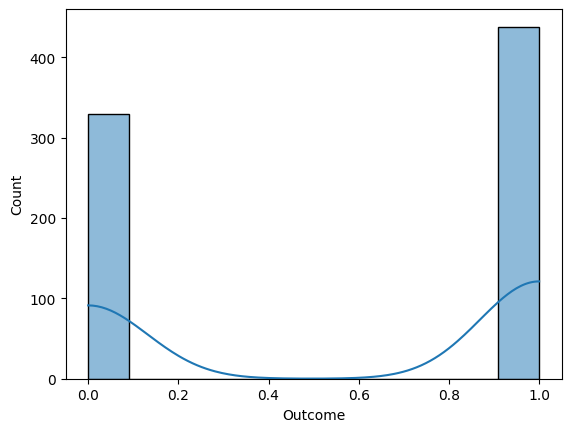

In [14]:
sns.histplot(df['Outcome'],kde=True)

<Axes: ylabel='Outcome'>

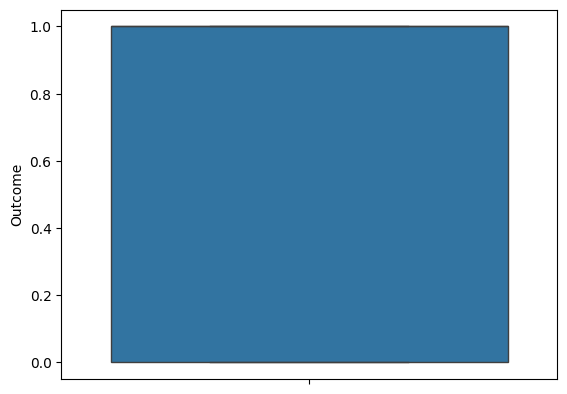

In [15]:
sns.boxplot(df['Outcome'])

<Axes: xlabel='Outcome'>

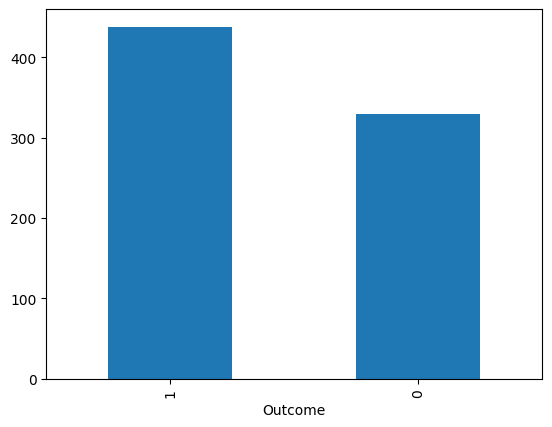

In [16]:
#countplot for checking class imbalnce->Difference between  your categorical values
# categorical values -2 values ->Binary Classification
#categorical values -more than 2 values->multiclass classification
df['Outcome'].value_counts().plot(kind='bar')


<Axes: ylabel='count'>

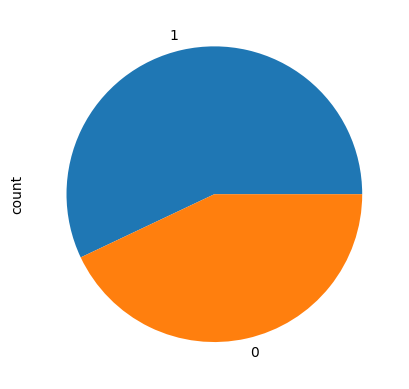

In [17]:
df['Outcome'].value_counts().plot(kind="pie")

<Axes: >

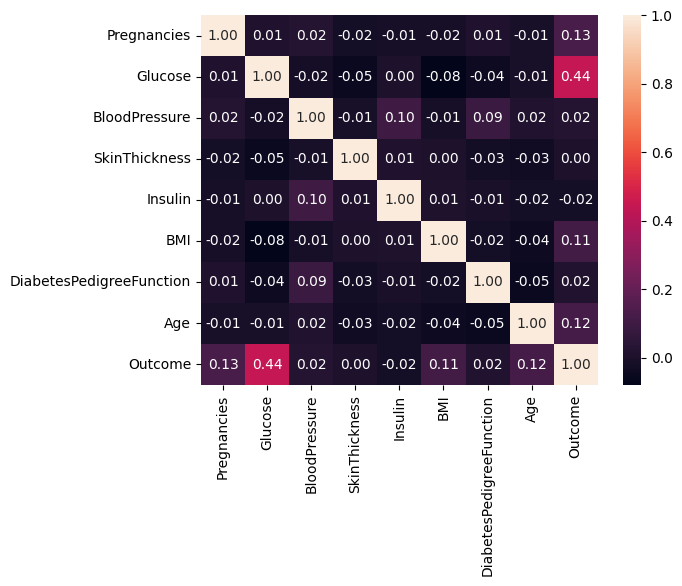

In [18]:
sns.heatmap(df.corr(),annot=True,fmt='.2f')

In [19]:
#split columns for training and testing
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [20]:
#we use standard scaler when we are working distance based algorithms
#when we are working on probability based on tree based algos we dont use it

In [21]:
#train test spilt
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
#boosting algorithm train
#Adaboost
#XGboost
#Gradient boost


In [23]:
#creating Adaboost model
from sklearn.ensemble import AdaBoostClassifier


In [24]:
Adaboost_model= AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
    )

In [25]:
Adaboost_model.fit(X_train,y_train)

AdaBoostClassifier(random_state=42)

In [26]:
#prediction on unseen data or xtest
Adaboost_Pred = Adaboost_model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,Adaboost_Pred)

0.6948051948051948

In [28]:
accuracy_score(y_train,Adaboost_model.predict(X_train))

0.754071661237785

In [29]:
#make a model of XGboost
from xgboost import XGBClassifier

In [30]:
XGBoost_model=XGBClassifier(
    n_estimators=10,
    learning_rate=0.05,
    random_state=42,
    max_depth=3,
)

In [31]:
XGBoost_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=10,
              n_jobs=None, num_parallel_tree=None, ...)

In [32]:
XGBoost_model_pred =XGBoost_model.predict(X_test)

In [33]:
XGBoost_model.predict(X_test)

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1])

In [34]:
accuracy_score(y_test,XGBoost_model_pred)

0.6168831168831169

In [35]:
accuracy_score(y_train,XGBoost_model.predict(X_train))

0.7345276872964169

In [36]:
#train test evaluate gradient boost model by your own
from sklearn.ensemble import GradientBoostingClassifier

In [37]:
GradientBoost_model=GradientBoostingClassifier(
    n_estimators=10,
    learning_rate=0.07,
    max_depth=2,
    random_state=42
)

In [38]:
GradientBoost_model.fit(X_train,y_train)

GradientBoostingClassifier(learning_rate=0.07, max_depth=2, n_estimators=10,
                           random_state=42)

In [39]:
Gradient_moel_pred=GradientBoost_model.predict(X_test)

In [40]:
accuracy_score(y_test,GradientBoost_model.predict(X_test))

0.6558441558441559

In [41]:
accuracy_score  (y_train,GradientBoost_model.predict(X_train))

0.7100977198697068

Testing on Naive bayes


In [42]:
from sklearn.naive_bayes import GaussianNB


In [43]:
naive_model=GaussianNB()

In [44]:
naive_model.fit(X_train,y_train)

GaussianNB()

In [45]:
accuracy_score(y_test,naive_model.predict(X_test))

0.7077922077922078

In [46]:
accuracy_score(y_train,naive_model.predict(X_train))

0.7296416938110749

In [54]:
# import naive bayes using joblib
import joblib
joblib.dump(naive_model,'diabetes_naive.pkl')

['diabetes_naive.pkl']